In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch version: 2.10.0+cpu
Using device: cpu


In [2]:
#--1.Tensor Basics--#
print("\n--- Tensor Basics --")
t1= torch.tensor([1.0, 2.0,3.0])
t2 = torch.zeros(3,4)
t3= torch.randn(3,4)
print("Shape:", t3.shape)
print("Dtype:", t3.dtype)
print("Matrix multiply shape:", (t3.T @ t3).shape)  # (4,4) 

# Convert to/from NumPy
arr  = np.array([1.0, 2.0, 3.0])
t    = torch.from_numpy(arr)
back = t.numpy()
print("NumPy → Tensor → NumPy:", back)




--- Tensor Basics --
Shape: torch.Size([3, 4])
Dtype: torch.float32
Matrix multiply shape: torch.Size([4, 4])
NumPy → Tensor → NumPy: [1. 2. 3.]

── Autograd ──


In [4]:
# ── 2. Autograd demo ──────────────────────────────
print("\n── Autograd ──")
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1   # y = x² + 2x + 1

y.backward()              # compute dy/dx
print(f"x={x.item()}, y={y.item()}, dy/dx={x.grad.item()}")  # dy/dx = 2x+2 = 8

# Gradient of a simple linear operation
w = torch.randn(4, 3, requires_grad=True)
b = torch.randn(3,    requires_grad=True)
x = torch.randn(5, 4)

out  = x @ w + b          # shape (5,3)
loss = out.sum()
loss.backward()
print("w.grad shape:", w.grad.shape)   # (4,3) — same as w
print("b.grad shape:", b.grad.shape)   # (3,)




── Autograd ──
x=3.0, y=16.0, dy/dx=8.0
w.grad shape: torch.Size([4, 3])
b.grad shape: torch.Size([3])


In [5]:
# ── 3. Build a model with nn.Module ───────────────
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)

model = IrisNet().to(device)
print("\n── Model Architecture ──")
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")


── Model Architecture ──
IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)
Total parameters: 243


In [6]:
# ── 4. Prepare data ───────────────────────────────
iris    = load_iris()
X, y    = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

In [7]:
# ── 5. Training loop ──────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, test_losses = [], []

print("\n── Training ──")
for epoch in range(300):
    model.train()

    # --- 4-step PyTorch training loop ---
    optimizer.zero_grad()              # 1. clear old gradients
    preds = model(X_train_t)           # 2. forward pass
    loss  = criterion(preds, y_train_t)# 3. compute loss
    loss.backward()                    # 4. backprop
    optimizer.step()                   # 5. update weights

    # Validation (no gradient needed)
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t)
        test_loss  = criterion(test_preds, y_test_t)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 50 == 0:
        train_acc = (preds.argmax(1) == y_train_t).float().mean()
        test_acc  = (test_preds.argmax(1) == y_test_t).float().mean()
        print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")



── Training ──
Epoch   0 | Train Loss: 1.1204 | Test Loss: 1.1005 | Train Acc: 0.3333 | Test Acc: 0.3333
Epoch  50 | Train Loss: 0.1736 | Test Loss: 0.1176 | Train Acc: 0.9500 | Test Acc: 0.9667
Epoch 100 | Train Loss: 0.0454 | Test Loss: 0.0125 | Train Acc: 0.9833 | Test Acc: 1.0000
Epoch 150 | Train Loss: 0.0428 | Test Loss: 0.0092 | Train Acc: 0.9833 | Test Acc: 1.0000
Epoch 200 | Train Loss: 0.0412 | Test Loss: 0.0088 | Train Acc: 0.9833 | Test Acc: 1.0000
Epoch 250 | Train Loss: 0.0394 | Test Loss: 0.0084 | Train Acc: 0.9833 | Test Acc: 1.0000


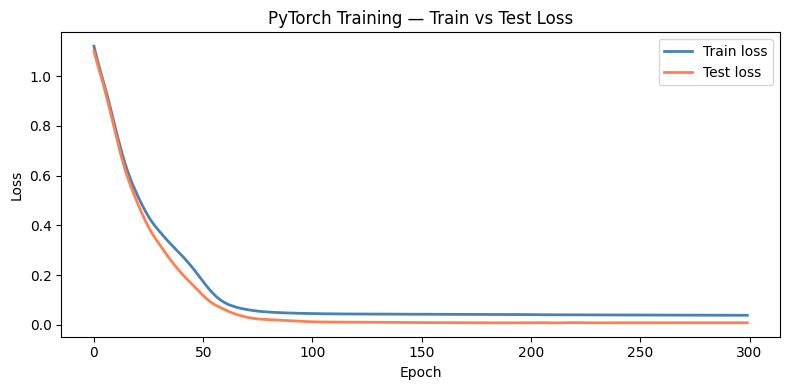

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss', color='steelblue', lw=2)
plt.plot(test_losses,  label='Test loss',  color='coral',     lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch Training — Train vs Test Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# ── 7. Final evaluation ───────────────────────────
model.eval()
with torch.no_grad():
    final_preds = model(X_test_t).argmax(1)
    acc = (final_preds == y_test_t).float().mean()
    print(f"\nFinal Test Accuracy: {acc:.4f}")


Final Test Accuracy: 1.0000
